In [10]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
# Category 3 videos include people moving around in the screen
video_files = [video.name for video in os.scandir('data') if video.is_dir()]

rand_video = np.random.choice(video_files)

In [18]:
def get_facial_landmarks(filename):
    with open(filename) as f:
        data = f.readlines()

    combined = ' '.join(data)
    start = combined.index("{") + 3
    end = combined.index("}")
    points = [coord.split(" ") for coord in combined[start:end].strip().split("\n ")]
    points = np.array(points).astype(float)

    return points

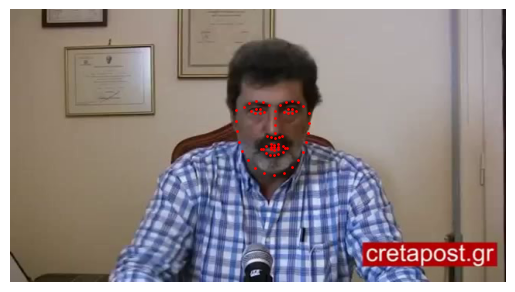

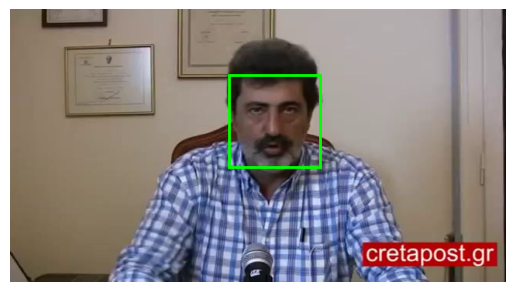

In [ ]:
# Load detector
detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(f"data/{rand_video}/vid.avi")
i = 1

while True:
    ret, frame = cap.read()
    if not ret or frame is None or frame.size == 0:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    detections = detector.detectMultiScale(gray,
                                            scaleFactor=1.1,
                                            minNeighbors=5,
                                            minSize=(60, 60))

    if len(detections) > 0:        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.imshow(frame_rgb)
        plt.axis('off')
        points = get_facial_landmarks(f"data/{rand_video}/annot/{i:06}.pts")
        plt.scatter(points[:, 0], points[:, 1], s=1, color=(1, 0, 0))
        plt.savefig('plots/face_example.png', dpi=200, bbox_inches='tight')
        plt.show()

        x, y, w, h = detections[0]
        fig, ax = plt.subplots()
        ax.imshow(frame_rgb)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=(0, 1, 0), facecolor='none')
        ax.add_patch(rect)
        plt.axis('off')
        plt.savefig('plots/detection_example.png', dpi=200, bbox_inches='tight')
        plt.show()
        break

    i += 1
        

cap.release()